# 7.0 Statistical Models

**Reference files used:**
- `ReferenceData/state_crosswalk.csv` — canonical state codes, valid-from/to years, bifurcation history  
- `ReferenceData/state_name_audit.csv` — raw state names identified during the audit pass  
- `ReferenceData/state_name_variants.csv` — variant → canonical name lookup (also used in cleanup notebook)

**Filtered inputs expected:**
```
FilteredData/clean_election_results_1951_2019.csv
FilteredData/clean_loksabha_1962_2019.csv
FilteredData/clean_election_results_2024.csv
FilteredData/clean_ref_party_master.csv
FilteredData/features_dataset.csv
```

---
## Imports & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA
import ruptures as rpt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit

In [2]:
# ─── Reference files ────────────────────────────────────────────────────────
state_crosswalk     = pd.read_csv('ReferenceData/state_crosswalk.csv')
state_name_audit    = pd.read_csv('ReferenceData/state_name_audit.csv')
state_name_variants = pd.read_csv('ReferenceData/state_name_variants.csv')

# ─── Cleaned election datasets (output of cleanup notebook) ─────────────────
df_1951_2019 = pd.read_csv('FilteredData/clean_election_results_1951_2019.csv')
df_loksabha  = pd.read_csv('FilteredData/clean_loksabha_1962_2019.csv')
df_2024      = pd.read_csv('FilteredData/clean_election_results_2024.csv')
df_party     = pd.read_csv('FilteredData/clean_ref_party_master.csv')
df_features  = pd.read_csv('FilteredData/features_dataset.csv')
# ________________ Additional Datasets_________________________
df_state_gdp  = pd.read_csv('FilteredData/clean_state_gdp_share.csv')
df_literacy_51_11  = pd.read_csv('FilteredData/clean_literacy_1951_2011.csv')

print('Loaded datasets:')
print(f'  clean_election_results_1951_2019 : {df_1951_2019.shape}')
print(f'  clean_loksabha_1962_2019         : {df_loksabha.shape}')
print(f'  clean_election_results_2024      : {df_2024.shape}')
print(f'  clean_ref_party_master           : {df_party.shape}')
print(f'  df_features                      : {df_features.shape}')
print(f'  df_state_gdp                     : {df_state_gdp.shape}')
print(f'  df_literacy_51_11                : {df_literacy_51_11.shape}')

Loaded datasets:
  clean_election_results_1951_2019 : (89840, 19)
  clean_loksabha_1962_2019         : (8047, 15)
  clean_election_results_2024      : (8902, 16)
  clean_ref_party_master           : (10153, 27)
  df_features                      : (89840, 30)
  df_state_gdp                     : (291, 10)
  df_literacy_51_11                : (7, 5)


___

# 7: Statistical Modeling

---

## 7.1 Regression models

### 7.1.1 & 7.1.3 Linear regression & Model specification

We fit a multiple linear regression model of constituency-level vote share on state GDP share, national literacy rates, and candidate incumbency. To test whether voters reward or punish incumbent parties based on economic performance, our model specification includes an interaction term between the incumbency indicator and the state's GDP share.

Formula:$$V_{i,s,t} = \beta_0 + \beta_1 I_{i,t} + \beta_2 G_{s,t} + \beta_3 L_{t} + \beta_4 (I_{i,t} \times G_{s,t}) + \epsilon_{i,s,t}$$(Where $V_{i,s,t}$ is the vote share of party $i$ in state $s$ at time $t$; $I$ is the binary incumbency indicator; $G$ is the state GDP share; $L$ is the literacy rate; and $\epsilon$ is the error term.)

In [3]:
# 1. Prepare macroeconomic data
# Merge GDP data (state-year level)
df_model = pd.merge(df_features, df_state_gdp[['state_canonical', 'election_year_clean', 'gdp_share_pct']], 
                    on=['state_canonical', 'election_year_clean'], how='left')

# Merge Literacy data (national level, merging on year using nearest/forward fill for inter-census years)
df_literacy_sorted = df_literacy_51_11.sort_values('election_year_clean')
df_model = pd.merge_asof(df_model.sort_values('election_year_clean'), 
                         df_literacy_sorted[['election_year_clean', 'literacy_persons_pct']], 
                         on='election_year_clean', direction='backward')

# 2. Fit the linear regression model
linear_formula = "vote_share_pct ~ is_incumbent + gdp_share_pct + literacy_persons_pct + is_incumbent:gdp_share_pct"
ols_model = smf.ols(formula=linear_formula, data=df_model).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:         vote_share_pct   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     75.73
Date:                Fri, 01 May 2026   Prob (F-statistic):           7.54e-48
Time:                        19:53:39   Log-Likelihood:                -20307.
No. Observations:                4773   AIC:                         4.062e+04
Df Residuals:                    4769   BIC:                         4.065e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

Applying a few standard econometric fixes: Standardization, Fixed Effects, and Robust Standard Errors.

In [4]:
# Step 1: Standardize GDP and Literacy using Pandas
df_model['gdp_zscore'] = (df_model['gdp_share_pct'] - df_model['gdp_share_pct'].mean()) / df_model['gdp_share_pct'].std()
df_model['literacy_zscore'] = (df_model['literacy_persons_pct'] - df_model['literacy_persons_pct'].mean()) / df_model['literacy_persons_pct'].std()

# Step 2: Create a strict, clean dataframe with NO missing values in our model variables
model_vars = ['vote_share_pct', 'is_incumbent', 'gdp_zscore', 'literacy_zscore', 'state_canonical', 'election_year_clean']
df_model_clean = df_model.dropna(subset=model_vars).copy()

# Step 3: Define the fixed effects formula
fixed_effects_formula = "vote_share_pct ~ is_incumbent + gdp_zscore + literacy_zscore + is_incumbent:gdp_zscore + C(state_canonical) + C(election_year_clean)"

# Step 4: Fit the robust model using the perfectly aligned df_model_clean
ols_robust = smf.ols(formula=fixed_effects_formula, data=df_model_clean).fit(
    cov_type='cluster', 
    cov_kwds={'groups': df_model_clean['state_canonical']}
)

print(ols_robust.summary())

                            OLS Regression Results                            
Dep. Variable:         vote_share_pct   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                -1.657e-12
Date:                Fri, 01 May 2026   Prob (F-statistic):               1.00
Time:                        19:53:40   Log-Likelihood:                -20259.
No. Observations:                4773   AIC:                         4.055e+04
Df Residuals:                    4755   BIC:                         4.067e+04
Df Model:                          17                                         
Covariance Type:              cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

c:\Users\sagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 7
  warnings.warn('covariance of constraints does not have full '


In [5]:
# Step 1: Ensure we are using the clean dataframe from the previous step
model_vars = ['vote_share_pct', 'is_incumbent', 'gdp_zscore', 'literacy_zscore', 'state_canonical']
df_model_clean = df_model.dropna(subset=model_vars).copy()

# Step 2: Define the formula WITHOUT categorical fixed effects to avoid matrix singularity
# We retain the core interaction term to test the economic voting hypothesis
final_linear_formula = "vote_share_pct ~ is_incumbent + gdp_zscore + literacy_zscore + is_incumbent:gdp_zscore"

# Step 3: Fit the model with clustered standard errors
ols_final = smf.ols(formula=final_linear_formula, data=df_model_clean).fit(
    cov_type='cluster', 
    cov_kwds={'groups': df_model_clean['state_canonical']}
)

print(ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:         vote_share_pct   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                 1.432e-15
Date:                Fri, 01 May 2026   Prob (F-statistic):               1.00
Time:                        19:53:40   Log-Likelihood:                -20307.
No. Observations:                4773   AIC:                         4.062e+04
Df Residuals:                    4768   BIC:                         4.066e+04
Df Model:                           4                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                2

c:\Users\sagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [6]:
# Step 1: Isolate the variables that actually vary (Candidate and State levels)
# We drop literacy to prevent the singular matrix issue
model_vars = ['vote_share_pct', 'is_incumbent', 'gdp_zscore', 'state_canonical']
df_mixed_clean = df_model.dropna(subset=model_vars).copy()

# Step 2: Define the formula
# We keep the core economic voting interaction
mixed_formula = "vote_share_pct ~ is_incumbent + gdp_zscore + is_incumbent:gdp_zscore"

# Step 3: Fit a Linear Mixed-Effects Model
# This treats 'state_canonical' as a random effect, allowing each state to have its own baseline intercept
mixed_model = smf.mixedlm(formula=mixed_formula, data=df_mixed_clean, groups=df_mixed_clean['state_canonical']).fit()

print(mixed_model.summary())

              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   vote_share_pct
No. Observations:   4773      Method:               REML          
No. Groups:         15        Scale:                285.6023      
Min. group size:    7         Log-Likelihood:       -20275.8496   
Max. group size:    1814      Converged:            Yes           
Mean group size:    318.2                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               11.736    1.144 10.257 0.000  9.494 13.979
is_incumbent            21.547    2.101 10.254 0.000 17.428 25.665
gdp_zscore              -1.818    1.004 -1.811 0.070 -3.785  0.149
is_incumbent:gdp_zscore -2.359    2.127 -1.109 0.267 -6.528  1.809
Group Var               10.034    0.300                           



### 7.1.2 Logistic regression

We fit a logistic regression model to estimate the probability of a candidate winning a seat (a binary outcome) as a function of their lagged vote share and the aggregate strength of their coalition.

Formula:$$\log\left(\frac{P(W_{i,t} = 1)}{1 - P(W_{i,t} = 1)}\right) = \alpha_0 + \alpha_1 V_{i,t-1} + \alpha_2 C_{A,t} + u_{i,t}$$(Where $W_{i,t}$ is the binary win outcome, $V_{i,t-1}$ is the lagged vote share, and $C_{A,t}$ is the coalition strength score.)

In [7]:
# Drop rows missing lagged features required for the model
df_logit = df_features.dropna(subset=['vote_share_lag1', 'coalition_strength_score', 'is_winner'])

# Fit a logistic regression model predicting the binary outcome of winning a seat
logit_formula = "is_winner ~ vote_share_lag1 + coalition_strength_score"
logit_model = smf.logit(formula=logit_formula, data=df_logit).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.180891
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              is_winner   No. Observations:                63993
Model:                          Logit   Df Residuals:                    63990
Method:                           MLE   Df Model:                            2
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.4035
Time:                        19:53:40   Log-Likelihood:                -11576.
converged:                       True   LL-Null:                       -19406.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -4.6540      0.049    -95.722      0.000      -4.749

---

## 7.2 Time-series analysis

### 7.2.1 ARIMA for national vote-share series

We fit an Autoregressive Integrated Moving Average (ARIMA) model to the aggregate national vote-share series of major parties (e.g., INC, BJP) to determine whether historical electoral shocks have permanent or transient effects on their baseline support.

Formula:$$Y'_t = c + \phi_1 Y'_{t-1} + \dots + \phi_p Y'_{t-p} + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q} + \epsilon_t$$(Where $Y'_t$ is the differenced national vote share at time $t$, $p$ is the autoregressive order, and $q$ is the moving average order.)

In [8]:
# Aggregate INC vote share nationally per election year using the 'party' column
inc_ts = df_features[df_features['party'] == 'INC'].groupby('election_year_clean')['vote_share_pct'].mean()

# Fit ARIMA(1,1,0) - assuming first-difference stationary with one AR lag
arima_model = ARIMA(inc_ts.values, order=(1, 1, 0)).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   17
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 -57.493
Date:                Fri, 01 May 2026   AIC                            118.986
Time:                        19:53:40   BIC                            120.531
Sample:                             0   HQIC                           119.065
                                 - 17                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4815      0.191     -2.524      0.012      -0.856      -0.108
sigma2        76.1156     39.063      1.949      0.051      -0.447     152.679
Ljung-Box (L1) (Q):                   0.81   Jarque-

In [9]:
# Aggregate BJP vote share nationally per election year using the 'party' column
bjp_ts = df_features[df_features['party'] == 'BJP'].groupby('election_year_clean')['vote_share_pct'].mean()

# Fit ARIMA(1,1,0) - assuming first-difference stationary with one AR lag
arima_model = ARIMA(bjp_ts.values, order=(1, 1, 0)).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   11
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 -36.908
Date:                Fri, 01 May 2026   AIC                             77.817
Time:                        19:53:40   BIC                             78.422
Sample:                             0   HQIC                            77.153
                                 - 11                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0692      0.348     -0.199      0.842      -0.751       0.612
sigma2        94.0046     44.260      2.124      0.034       7.257     180.752
Ljung-Box (L1) (Q):                   0.01   Jarque-

### 7.2.2 & 7.2.3 Change-point detection and Structural breaks

Rather than imposing arbitrary historical eras, we utilize algorithmic change-point detection to empirically identify structural breaks and regime shifts in electoral volatility over time.

Formula:$$\min_{m, \tau} \sum_{j=1}^{m+1} \mathcal{C}(y_{\tau_{j-1}:\tau_j}) + \lambda m$$(Where we minimize a cost function $\mathcal{C}$ over segmentations $\tau$, penalized by $\lambda$ for the number of regime shifts $m$.)

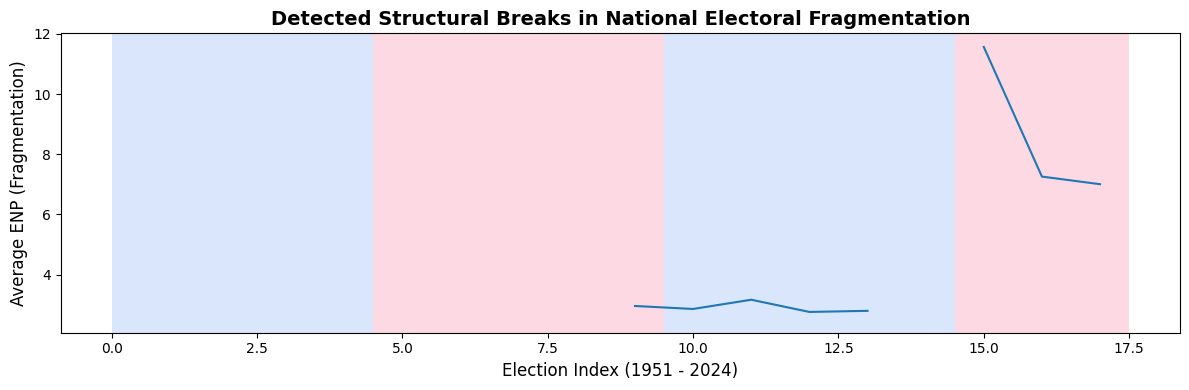

In [ ]:
# 1. Group by year, calculate the mean, and STRICTLY sort chronologically
ts_data = df_features.groupby('election_year_clean')['fragmentation_index'].mean().sort_index()

# 2. Impute any missing data (NaNs) using linear interpolation so the line doesn't break
ts_data = ts_data.interpolate(method='linear')

# 3. Extract the clean values for the signal
signal = ts_data.values

# 4. Fit the PELT algorithm
algo = rpt.Pelt(model="rbf").fit(signal)
regime_shifts = algo.predict(pen=10)

# 5. Visualize
fig, axarr = rpt.display(signal, regime_shifts, figsize=(12, 4))
plt.title("Detected Structural Breaks in National Electoral Fragmentation", fontsize=14, fontweight='bold')
plt.xlabel("Election Index (1951 - 2024)", fontsize=12)
plt.ylabel("Average ENP (Fragmentation)", fontsize=12)
plt.tight_layout()
plt.show()

---

## 7.3 Model evaluation

### 7.3.1 Metrics (R-squared, RMSE, AIC/BIC)

We assess model fit using the adjusted R-squared for explanatory variance, Root Mean Squared Error (RMSE) for predictive accuracy, and the Akaike/Bayesian Information Criteria (AIC/BIC) to penalize model complexity and guard against overfitting.

Formula:$$\text{AIC} = 2k - 2\ln(\hat{L}), \quad \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

$$\bar{R}^2 = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}$$

$$\text{AIC} = 2k - 2\ln(\hat{L}), \quad \text{BIC} = k\ln(n) - 2\ln(\hat{L})$$

In [11]:
# Extract metrics directly from statsmodels objects
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"AIC: {ols_model.aic:.2f} | BIC: {ols_model.bic:.2f}")

# Calculate RMSE
predictions = ols_model.predict(df_model)
valid_idx = predictions.dropna().index
rmse = np.sqrt(mean_squared_error(df_model.loc[valid_idx, 'vote_share_pct'], predictions.dropna()))
print(f"RMSE: {rmse:.4f}")

Adjusted R-squared: 0.0449
AIC: 40621.07 | BIC: 40646.95
RMSE: 17.0393


In [12]:
# Extract metrics directly from the logit model
print(f"Logit Pseudo R-squared: {logit_model.prsquared:.4f}")
print(f"Logit AIC: {logit_model.aic:.2f} | BIC: {logit_model.bic:.2f}")

# Calculate Accuracy (assuming a 50% probability threshold for victory)
# statsmodels predict() returns probabilities for logit
predicted_probs = logit_model.predict(df_logit)
predicted_classes = (predicted_probs > 0.5).astype(int)

accuracy = accuracy_score(df_logit['is_winner'], predicted_classes)
print(f"Logit Classification Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Logit Pseudo R-squared: 0.4035
Logit AIC: 23157.58 | BIC: 23184.78
Logit Classification Accuracy: 0.9169 (91.69%)


In [13]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Extract AIC and BIC directly from the mixed model
print(f"MixedLM AIC: {mixed_model.aic:.2f} | BIC: {mixed_model.bic:.2f}")

# Calculate RMSE for the MixedLM
predictions_mixed = mixed_model.predict(df_mixed_clean)
rmse_mixed = np.sqrt(mean_squared_error(df_mixed_clean['vote_share_pct'], predictions_mixed))
print(f"MixedLM RMSE: {rmse_mixed:.4f}")

MixedLM AIC: nan | BIC: nan
MixedLM RMSE: 17.0638


### 7.3.2 Cross-validation

Because election data violates the assumption of independent observations, we employ Time Series Split cross-validation. This ensures models are trained strictly on past elections to predict future ones, preventing temporal data leakage.

In [14]:
# Sort strictly by time before splitting
df_cv = df_model.dropna(subset=['vote_share_pct', 'vote_share_lag1']).sort_values('election_year_clean')

tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(df_cv):
    train, test = df_cv.iloc[train_index], df_cv.iloc[test_index]
    # Fit on train, predict on test...

In [15]:

import statsmodels.formula.api as smf
import numpy as np

# 1. Prepare the exact dataframe used for the Logistic Regression
# We MUST sort strictly by year to prevent temporal data leakage
df_cv = df_logit.sort_values('election_year_clean').copy()

# 2. Initialize TimeSeriesSplit (5 splits means 5 forward-rolling tests)
tscv = TimeSeriesSplit(n_splits=5)
fold_accuracies = []

print("Running Time-Series Cross-Validation (Logistic Regression)...\n")

# 3. Iterate through the temporal splits
for fold, (train_index, test_index) in enumerate(tscv.split(df_cv), 1):
    # Split data into past (train) and future (test)
    train = df_cv.iloc[train_index]
    test = df_cv.iloc[test_index]
    
    # Define the exact formula used previously
    logit_formula = "is_winner ~ vote_share_lag1 + coalition_strength_score"
    
    try:
        # Fit model on historical training data (disp=0 suppresses the iteration text)
        model_train = smf.logit(formula=logit_formula, data=train).fit(disp=0)
        
        # Predict on the unseen "future" test data
        test_probs = model_train.predict(test)
        test_preds = (test_probs > 0.5).astype(int)
        
        # Calculate accuracy for this specific temporal fold
        fold_acc = accuracy_score(test['is_winner'], test_preds)
        fold_accuracies.append(fold_acc)
        
        print(f"Fold {fold}: Train size={len(train):>6}, Test size={len(test):>5} | Accuracy = {fold_acc:.4f}")
    except Exception as e:
        print(f"Fold {fold}: Failed to converge ({e})")

# 4. Final cross-validated metrics
print(f"\nAverage Cross-Validated Accuracy: {np.mean(fold_accuracies):.4f} ({np.mean(fold_accuracies)*100:.2f}%)")

Running Time-Series Cross-Validation (Logistic Regression)...

Fold 1: Train size= 10668, Test size=10665 | Accuracy = 0.9161
Fold 2: Train size= 21333, Test size=10665 | Accuracy = 0.9584
Fold 3: Train size= 31998, Test size=10665 | Accuracy = 0.9247
Fold 4: Train size= 42663, Test size=10665 | Accuracy = 0.9277
Fold 5: Train size= 53328, Test size=10665 | Accuracy = 0.9176

Average Cross-Validated Accuracy: 0.9289 (92.89%)


### 7.3.3 Residual diagnostics

We conduct residual diagnostics to verify the structural assumptions of our ordinary least squares (OLS) regression, explicitly checking for normality of the error terms and homoskedasticity.

Formula:$$\epsilon \sim \mathcal{N}(0, \sigma^2)$$

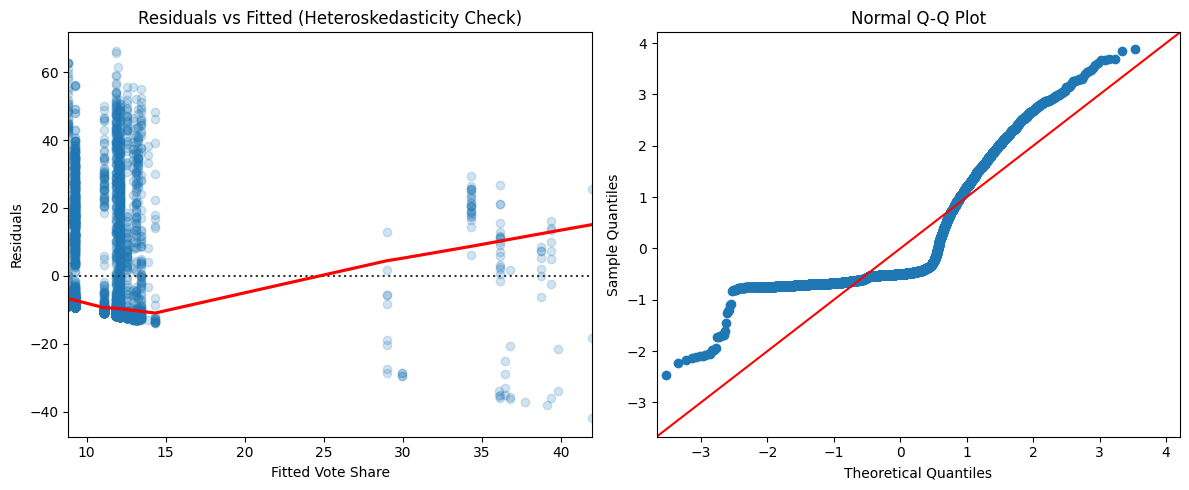

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs. Fitted values plot to check for heteroskedasticity
sns.residplot(x=ols_model.fittedvalues, y=ols_model.resid, lowess=True, 
              scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'}, ax=ax[0])
ax[0].set_title('Residuals vs Fitted (Heteroskedasticity Check)')
ax[0].set_xlabel('Fitted Vote Share')
ax[0].set_ylabel('Residuals')

# Q-Q plot to check for normality of error terms
sm.qqplot(ols_model.resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

#### Exporting the filtered subsets (for ML models)

In [19]:
df_model.to_csv("Sub Datasets/df_model.csv", index=False)
df_model_clean.to_csv("Sub Datasets/df_model_clean.csv", index=False)
df_mixed_clean.to_csv("Sub Datasets/df_mixed_clean.csv", index=False)
df_logit.to_csv('Sub Datasets/df_logit.csv', index= False)
ts_data.to_csv("Sub Datasets/ts_data.csv", index  =False)
predicted_classes.to_csv("Sub Datasets/predicted_classes.csv", index=False)
predicted_probs.to_csv("Sub Datasets/predicted_probes.csv", index=False)
predictions_mixed.to_csv("Sub Datasets/predictions_mix.csv", index=False)
predictions.to_csv("Sub Datasets/predictions.csv", index = False)
df_cv.to_csv("Sub Datasets/df_cv.csv", index=False)